In [1]:
#Loading dataset
import pandas as pd

df = pd.read_csv("online_shoppers_preprocessed.csv")

print(df.shape)
df.head()

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,2,False,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,2,False,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,2,False,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,2,False,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,2,True,0


In [2]:
#Split dataset features and target
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)



In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)  # fit ONLY on training
X_test = scaler.transform(X_test)        # transform test

In [4]:
print(X_train.mean())
print(X_train.std())

1.093220897297993e-17
0.9999999999999999


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

log_model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    solver="lbfgs"
)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.872683673161761
              precision    recall  f1-score   support

           0       0.94      0.89      0.92      2084
           1       0.55      0.71      0.62       382

    accuracy                           0.86      2466
   macro avg       0.75      0.80      0.77      2466
weighted avg       0.88      0.86      0.87      2466



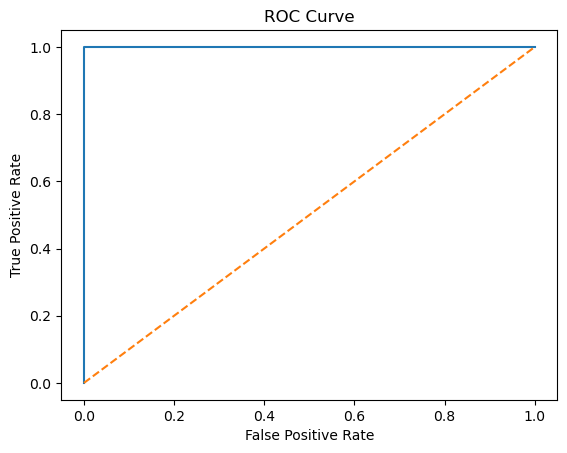

In [6]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_pred, y_proba)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

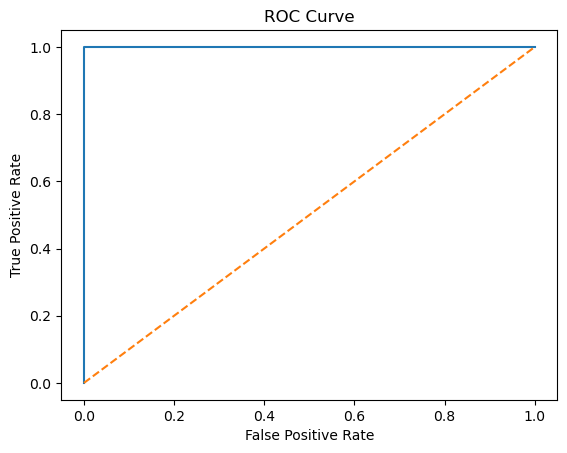

In [10]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_rf, tpr_rf, _ = roc_curve(y_pred_rf, y_proba_rf)

plt.plot(fpr_rf, tpr_rf)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

import numpy as np

threshold = 0.35  # try 0.4, 0.35, 0.3

y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = (y_proba_rf >= threshold).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))

'''
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))'''

ROC-AUC: 0.9202048014792336
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      2084
           1       0.64      0.69      0.66       382

    accuracy                           0.89      2466
   macro avg       0.79      0.81      0.80      2466
weighted avg       0.89      0.89      0.89      2466



'\ny_pred_rf = rf_model.predict(X_test)\ny_proba_rf = rf_model.predict_proba(X_test)[:, 1]\n\nprint("Random Forest ROC-AUC:", roc_auc_score(y_test, y_proba_rf))\nprint(classification_report(y_test, y_pred_rf))'

In [11]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

# Calculate imbalance ratio
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_proba_xgb >= 0.5).astype(int)

print("XGBoost ROC-AUC:", roc_auc_score(y_pred_xgb, y_proba_xgb))
print(classification_report(y_test, y_pred_xgb))


XGBoost ROC-AUC: 0.9208102621820703
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      2084
           1       0.60      0.75      0.67       382

    accuracy                           0.88      2466
   macro avg       0.78      0.83      0.80      2466
weighted avg       0.90      0.88      0.89      2466



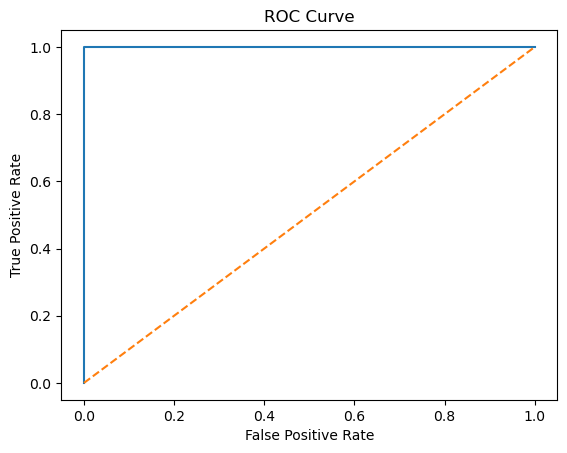

In [12]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_xgb, tpr_xgb, _ = roc_curve(y_pred_xgb, y_proba_xgb)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

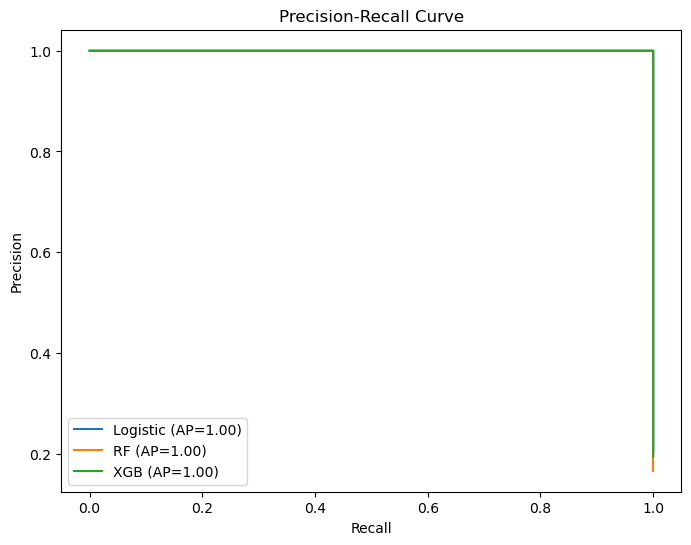

In [13]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Logistic
precision_log, recall_log, _ = precision_recall_curve(y_pred, y_proba)
ap_log = average_precision_score(y_pred, y_proba)
plt.plot(recall_log, precision_log, label=f"Logistic (AP={ap_log:.2f})")

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_pred_rf, y_proba_rf)
ap_rf = average_precision_score(y_pred_rf, y_proba_rf)
plt.plot(recall_rf, precision_rf, label=f"RF (AP={ap_rf:.2f})")

# XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(y_pred_xgb, y_proba_xgb)
ap_xgb = average_precision_score(y_pred_xgb, y_proba_xgb)
plt.plot(recall_xgb, precision_xgb, label=f"XGB (AP={ap_xgb:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [14]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.1, 0.9, 100)
best_f1 = 0
best_threshold = 0

for t in thresholds:
    preds = (y_proba_xgb >= t).astype(int)
    f1 = f1_score(y_test, preds)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

Best threshold: 0.4878787878787879
Best F1: 0.6728323699421966
